
BẢNG KẾT QUẢ


,Metric,Teacher (zero-shot),Teacher (fine-tuned),No-KD (baseline),Seq-KD (Student),Word-KD (Student),FitNets (Student),Attention Transfer (Student),Combined Response+Feature (Student)
0,BLEU,0.0124,0.3270,0.3267,0.3379,0.3450,0.3299,0.3412,0.3449
1,ROUGE-L,0.2179,0.5074,0.5060,0.5156,0.5262,0.5315,0.5231,0.5344
2,CIDEr,0.0403,0.8786,1.0494,0.9732,1.0180,1.2383,1.1725,1.2435


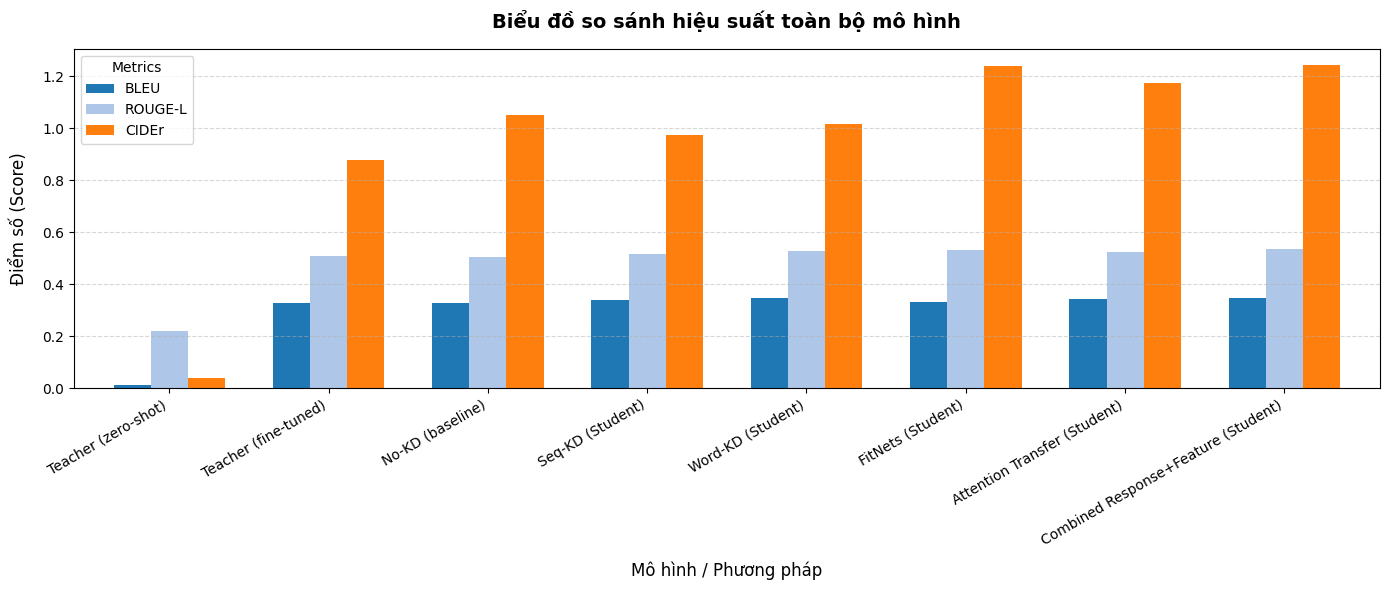

In [4]:
import json
import matplotlib.pyplot as plt
import pandas as pd

try:
    with open("results_file.json", "r", encoding="utf-8") as f:
        results = json.load(f)
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'results_file.json'.")
    exit()

col_order = list(results.keys())

data = {"Metric": ["BLEU", "ROUGE-L", "CIDEr"]}
for col in col_order:
    b, r, c = results[col]
    data[col] = [b, r, c]

df_results = pd.DataFrame(data).round(4)

print("\nBẢNG KẾT QUẢ")

try:
    display(df_results)
except NameError:
    print(df_results.to_string(index=False))

df_plot = df_results.set_index("Metric").T

fig, ax = plt.subplots(figsize=(14, 6))
df_plot.plot(kind="bar", width=0.7, color=["#1f77b4", "#aec7e8", "#ff7f0e"], ax=ax)

plt.title(
    "Biểu đồ so sánh hiệu suất toàn bộ mô hình",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Mô hình / Phương pháp", fontsize=12, labelpad=10)
plt.ylabel("Điểm số (Score)", fontsize=12, labelpad=10)

# Xoay chữ 30 độ để hiển thị đầy đủ tên của cả 8 mô hình mà không bị đè nhau
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Metrics", loc="upper left")

plt.tight_layout()
plt.show()